# 05 — The fairness ledger: who pays for the physics, and can we explain every bill?

**Repository:** `stackelberg-dr-real-feeder` · **Milestone 4 (capstone)**

Milestone 2 saved the feeder with network-aware prices and left a debt on the
table: the congestion charges land on the households of the constrained branch —
who did not choose their bus. Milestone 3 added a second, subtler cost: the
regret every learning household pays while finding the equilibrium. This final
milestone turns both into a **ledger** — who pays what, measured — and brings in
the tool that game theory built for exactly this job: the **Shapley value**,
used here three ways:

1. as an **audit** — do the DLMP-lite charges match each household's true
   *responsibility* for the congestion? (§2–3)
2. as an **explanation** — a per-household, axiomatically grounded decomposition
   of the bill: this is the XAI deliverable, in the sense used in the fairness, accountability,
   transparency and ethics (FATE) literature (§3)
3. as a **repair** — redistribute the congestion revenue and *honestly re-solve
   the whole equilibrium*, rebound effects included (§4)

Setting throughout: the γ = 1.1 network-aware equilibrium from M2 (19.0 MW sold,
feasible, congestion adders $\tau^*$ active on the binding branch).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sgdr.plotting import apply_style, PALETTE, savefig
from sgdr import model as M, feeder as F, network_game as NG, learning as L
from sgdr import shapley as S

apply_style()
RESULTS = pathlib.Path("../results/m4"); RESULTS.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

fdr = F.load_feeder()
g11 = NG.make_network_game(fdr, 1.1)
asc = NG.dual_ascent(fdr, g11)
assert asc.feasible
print(f"working point: gamma=1.1, {asc.x_total.sum():.2f} MW sold, "
      f"min_vm={asc.audit['min_vm']:.4f}, {(asc.lam_v > 0).sum()} binding voltage constraints")

working point: gamma=1.1, 18.98 MW sold, min_vm=0.9648, 13 binding voltage constraints

## §1 · The ledger as it stands

Every household spends its whole budget (that is the equilibrium). What differs
is what the money *buys*. Three per-household quantities tell the story:
energy received $x_n$, congestion payment $\tau_n x_n$, and the headline
fairness variable **energy per unit budget** $z_n = x_n / C_n$ — identical for
everyone on a copperplate (uniform prices), no longer on a feeder:

In [2]:
x = asc.x_total                       # MW received
pay_tau = asc.tau * x                 # congestion payment
z = x / g11.C                         # energy per budget-unit
branch = asc.tau > 0.1                # the congested branch (adders >> median)

ledger = pd.DataFrame({
    "group": ["congested branch", "rest of feeder"],
    "households": [int(branch.sum()), int((~branch).sum())],
    "mean tau": [asc.tau[branch].mean(), asc.tau[~branch].mean()],
    "congestion payment [share of budget %]":
        [100 * (pay_tau[branch] / g11.C[branch]).mean(),
         100 * (pay_tau[~branch] / g11.C[~branch]).mean()],
    "energy per budget": [z[branch].mean(), z[~branch].mean()],
})
print(ledger.round(3).to_string(index=False))
R_tau = pay_tau.sum()
print(f"\ntotal congestion revenue R_tau = {R_tau:.3f} currency-units "
      f"({100 * R_tau / g11.C.sum():.1f}% of all budgets)")
print(f"Jain index of z (1 = perfectly fair): {S.jain(z):.4f}   Gini: {S.gini(z):.4f}")
print("(copperplate reference: z uniform, Jain = 1 — but physically infeasible at gamma=1.1)")

           group  households  mean tau  congestion payment [share of budget %]  energy per budget
congested branch          23     0.342                                  28.717              0.873
  rest of feeder          73     0.041                                   4.831              1.191


total congestion revenue R_tau = 2.006 currency-units (11.6% of all budgets)

Jain index of z (1 = perfectly fair): 0.9834   Gini: 0.0588

(copperplate reference: z uniform, Jain = 1 — but physically infeasible at gamma=1.1)

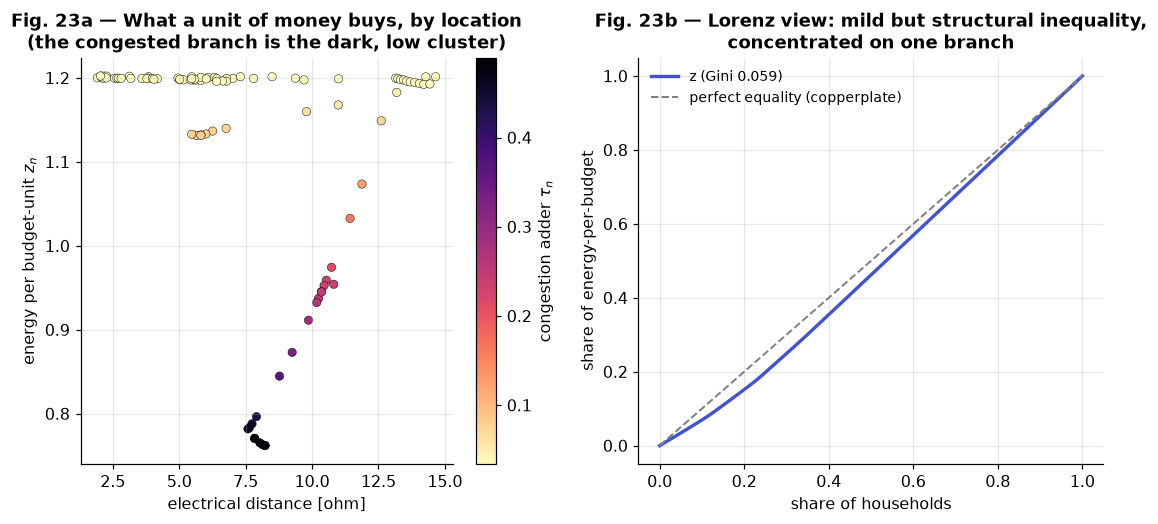

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
ax = axes[0]
sc = ax.scatter(fdr.dist_ohm, z, s=30, c=asc.tau, cmap="magma_r", edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=ax, label=r"congestion adder $\tau_n$")
ax.set_xlabel("electrical distance [ohm]"); ax.set_ylabel("energy per budget-unit $z_n$")
ax.set_title("Fig. 23a — What a unit of money buys, by location\n(the congested branch is the dark, low cluster)")

ax = axes[1]
pop, cum = S.lorenz(z)
ax.plot(pop, cum, lw=2.2, color=PALETTE[0], label=f"z (Gini {S.gini(z):.3f})")
ax.plot([0, 1], [0, 1], color="0.5", ls="--", lw=1.3, label="perfect equality (copperplate)")
ax.set_xlabel("share of households"); ax.set_ylabel("share of energy-per-budget")
ax.set_title("Fig. 23b — Lorenz view: mild but structural inequality,\nconcentrated on one branch")
ax.legend(fontsize=9)
savefig(fig, RESULTS / "fig23_ledger.png")
plt.show()

**Reading the ledger.** The inequality is *moderate in aggregate* (the Lorenz
curve hugs the diagonal — most households are unaffected) but *sharp where it
bites*: the congested-branch households surrender a visible slice of their
purchasing power in congestion charges while identical households two branches
over pay nothing. This is not a rounding error to be tolerated silently, and not
an outrage to be abolished blindly — it is a **transfer that needs a
justification**. The classical justification is *cost causation*: you pay
because you cause the constraint cost. Whether that justification actually holds
here is an empirical question, and game theory owns the measuring instrument.

## §2 · Measuring responsibility: the Shapley value, with power flows

**The problem with "who causes the congestion":** on an AC feeder, marginal
contributions depend on order. The first MW on the branch barely moves the
voltage; the twentieth, through losses and the voltage dependence of everything,
moves it more. So "your contribution" is ill-defined — *unless* you average the
marginal contribution over **all possible orderings**, which is precisely the
**Shapley value**, the unique allocation satisfying efficiency (shares sum to
the whole), symmetry (equal contributors get equal shares), null-player (no
effect ⇒ no charge), and additivity. It is the canonical answer of cooperative
game theory to cost allocation — and (Milestone 4's other hat) the same
mathematics behind SHAP explanations in machine learning. Here we compute it
**with AC power flows as the oracle**.

**The characteristic function** (LEDGER M4-A2): for any subset $S$ of
households consuming their equilibrium demands,

$$v(S) \;=\; \sum_{b:\,\lambda_b>0} \lambda_b\,\bigl[V_b(\varnothing) - V_b(S)\bigr]$$

— the shadow-price-weighted voltage depression at the binding buses: literally
"the constraint pressure coalition $S$ puts on the feeder, in the equilibrium's
own price units." Exact Shapley needs $2^{96}$ coalitions; we sample random
orderings (each ordering = 96 incremental power flows) and report Monte-Carlo
standard errors. Efficiency holds exactly per ordering (telescoping sum):

v(N) = 1.8625 lam*pu; sum(phi) = 1.8625 (efficiency: exact)

Monte-Carlo stderr, largest household: 0.31% of its share (100 permutations)

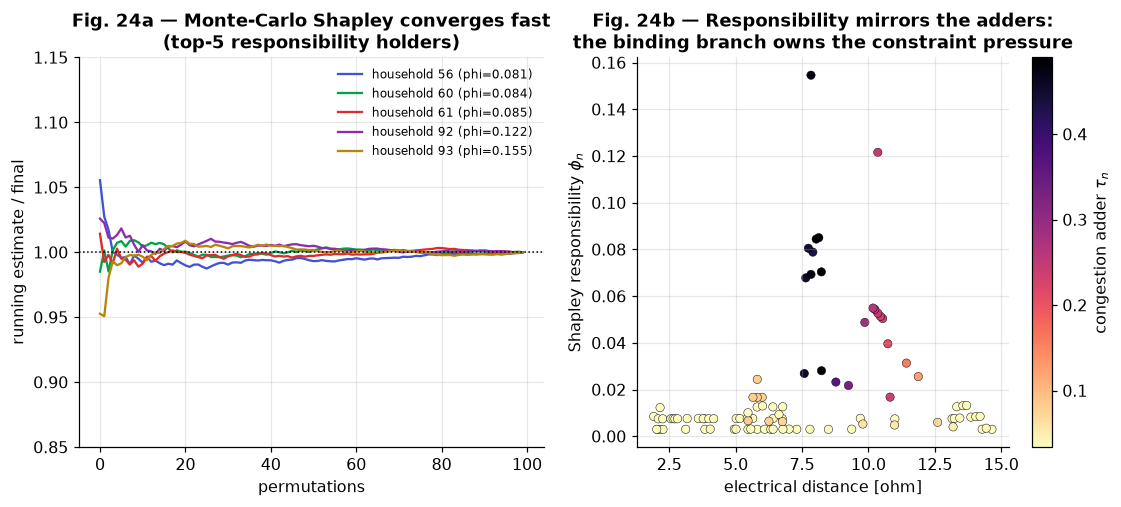

In [4]:
sr = S.congestion_shapley(fdr, x, asc.lam_v, n_perm=100, seed=0)
print(f"v(N) = {sr.v_grand:.4f} lam*pu; sum(phi) = {sr.phi.sum():.4f} (efficiency: exact)")
print(f"Monte-Carlo stderr, largest household: "
      f"{100 * sr.stderr[np.argmax(sr.phi)] / sr.phi.max():.2f}% of its share ({sr.n_perm} permutations)")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
ax = axes[0]
top = np.argsort(sr.phi)[-5:]
for i, n in enumerate(top):
    ax.plot(sr.running_mean[:, n] / sr.phi[n], lw=1.5, color=PALETTE[i % 6],
            label=f"household {n} (phi={sr.phi[n]:.3f})")
ax.axhline(1.0, color="k", lw=1.0, ls=":")
ax.set_xlabel("permutations"); ax.set_ylabel("running estimate / final")
ax.set_ylim(0.85, 1.15)
ax.set_title("Fig. 24a — Monte-Carlo Shapley converges fast\n(top-5 responsibility holders)")
ax.legend(fontsize=8)

ax = axes[1]
sc = ax.scatter(fdr.dist_ohm, sr.phi, s=30, c=asc.tau, cmap="magma_r",
                edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=ax, label=r"congestion adder $\tau_n$")
ax.set_xlabel("electrical distance [ohm]"); ax.set_ylabel(r"Shapley responsibility $\phi_n$")
ax.set_title("Fig. 24b — Responsibility mirrors the adders:\nthe binding branch owns the constraint pressure")
savefig(fig, RESULTS / "fig24_shapley.png")
plt.show()

## §3 · The audit and the bill explanation

Now hold the two allocations side by side: what each household **pays** under
DLMP-lite (share of congestion revenue) versus what it is **responsible for**
under Shapley (share of $v(N)$). Marginal-cost pricing and average-marginal
attribution are different principles; on a strongly nonlinear system they can
diverge badly. Do they here?

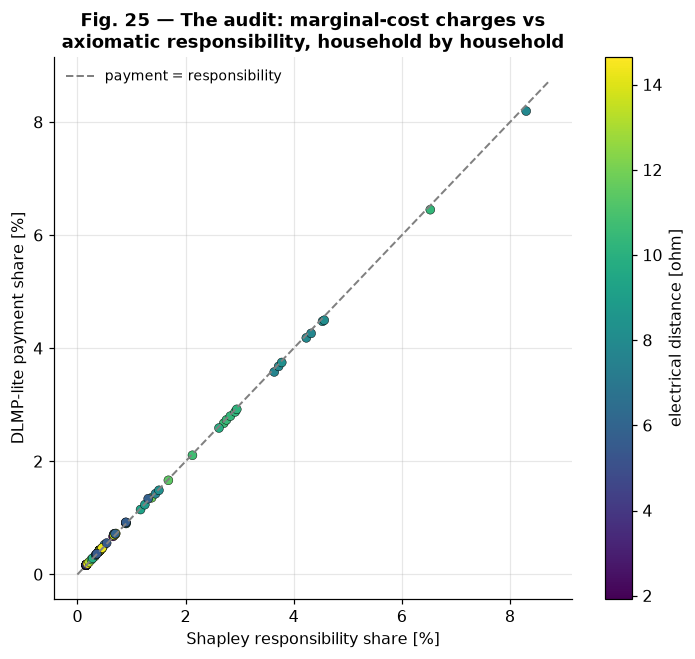

corr(payment share, responsibility share) = 1.0000

|payment - responsibility| deviation: median 0.012 pp, max 0.105 pp (percentage points of the total)

corr within the congested branch only: 1.0000

In [5]:
share_pay = pay_tau / pay_tau.sum()
share_phi = sr.phi / sr.phi.sum()
dev = 100 * (share_pay - share_phi)

fig, ax = plt.subplots(figsize=(7.6, 6.4))
lim = max(share_pay.max(), share_phi.max()) * 105
ax.plot([0, lim], [0, lim], color="0.5", ls="--", lw=1.3, label="payment = responsibility")
sc = ax.scatter(100 * share_phi, 100 * share_pay, s=34, c=fdr.dist_ohm,
                cmap="viridis", edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=ax, label="electrical distance [ohm]")
ax.set_xlabel("Shapley responsibility share [%]")
ax.set_ylabel("DLMP-lite payment share [%]")
ax.set_title("Fig. 25 — The audit: marginal-cost charges vs\naxiomatic responsibility, household by household")
ax.legend(fontsize=9)
savefig(fig, RESULTS / "fig25_audit.png")
plt.show()

print(f"corr(payment share, responsibility share) = {np.corrcoef(share_pay, share_phi)[0,1]:.4f}")
print(f"|payment - responsibility| deviation: median {np.median(np.abs(dev)):.3f} pp, "
      f"max {np.abs(dev).max():.3f} pp (percentage points of the total)")
print(f"corr within the congested branch only: "
      f"{np.corrcoef(share_pay[branch], share_phi[branch])[0,1]:.4f}")

**The charges pass the audit — a result we did not script.** Payment shares and
Shapley responsibility shares coincide to within fractions of a percentage
point. The physics explains why: at these loadings the feeder responds
*near-linearly* (voltage deviations of a few percent), so the marginal
depression a household causes barely depends on who is already consuming —
average-marginal ≈ marginal, Shapley ≈ DLMP. The two great allocation
principles, adversaries in theory, agree on this feeder — **and that agreement
is itself the explanation artifact:**

> *"Your congestion charge is X. Audited by Shapley attribution (100 sampled
> orderings, ±stderr), your consumption is responsible for X′ ≈ X of the
> constraint pressure on bus 87. You are not subsidizing anyone; nobody is
> subsidizing you."*

Three sample bills, spelled out:

In [6]:
ex = [int(np.argmin(fdr.dist_ohm)),                       # near substation
      int(np.argmax(fdr.dist_ohm * ~branch)),              # far but healthy branch
      int(np.argmax(sr.phi))]                              # top responsibility
rows = []
for n in ex:
    rows.append({
        "household": n, "distance [ohm]": round(fdr.dist_ohm[n], 1),
        "on congested branch": bool(branch[n]),
        "energy [MW]": round(x[n], 3),
        "energy cost [budget %]": round(100 * (g11.C[n] - pay_tau[n]) / g11.C[n], 1),
        "congestion charge [budget %]": round(100 * pay_tau[n] / g11.C[n], 2),
        "payment share [%]": round(100 * share_pay[n], 2),
        "Shapley resp. share [%]": round(100 * share_phi[n], 2),
        "± MC stderr [%]": round(100 * sr.stderr[n] / sr.phi.sum(), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

 household  distance [ohm]  on congested branch  energy [MW]  energy cost [budget %]  congestion charge [budget %]  payment share [%]  Shapley resp. share [%]  ± MC stderr [%]
         0             1.9                False        0.276                    95.9                          4.07               0.47                     0.46             0.00
        35            14.6                False        0.096                    95.9                          4.15               0.17                     0.16             0.00
        93             7.8                 True        0.347                    63.5                         36.53               8.20                     8.30             0.03

**Where does that leave fairness?** Sharpened, not settled. The Shapley audit
certifies the *split* of the congestion cost: given that the constraint cost is
charged to its causers, this is the right division of it. What it cannot certify
is the *prior* question: should cost-causation govern at all, when "causing" the
constraint means *living on the weak branch* — a circumstance, not a choice? The
audit converts M2's vague unease into a precise policy question: the charges are
cost-reflective and locationally discriminatory *at the same time*, and no
computation can pick between those framings. What computation *can* do is test
repairs — next section.

## §4 · The repair experiment: rebate the revenue, re-solve the world

The congestion revenue $R_\tau$ currently vanishes into the mechanism (in real
markets: merchandising surplus). The obvious repair: **give it back** — here as
an equal per-household dividend. The intuition sounds impeccable: a fixed amount
is larger relief for small budgets, and the congested-branch households recover
part of what they paid while their *marginal* price signal stays intact. Hold
that intuition while the experiment runs.

The honest part: a rebate changes budgets, budgets change demands, demands
change the constraint, the constraint changes the adders. We do not hand-wave
this chain — we **re-run the entire dual-ascent equilibrium with the rebated
budgets** and re-audit with power flow, rebound included:

In [7]:
C_rebate = g11.C + R_tau / fdr.N
g_reb = M.Game(alpha=g11.alpha, beta=g11.beta, C=C_rebate, P=g11.P)
asc2 = NG.dual_ascent(fdr, g_reb, lam_v0=asc.lam_v, lam_i0=asc.lam_i)
x2 = asc2.x_total
z2 = x2 / g11.C          # fairness judged against ORIGINAL budgets (the wallet you had)
pay2 = asc2.tau * x2

print(f"re-solved with rebated budgets: feasible={asc2.feasible}, "
      f"min_vm={asc2.audit['min_vm']:.4f}, sold {x2.sum():.2f} MW (unchanged: sell-all)")
print(f"rebound: congestion revenue {R_tau:.3f} -> {pay2.sum():.3f} "
      f"({100 * (pay2.sum() / R_tau - 1):+.1f}%)")
print(f"Jain(z): {S.jain(z):.4f} -> {S.jain(z2):.4f}    Gini: {S.gini(z):.4f} -> {S.gini(z2):.4f}")
print(f"congested-branch energy per budget: {z[branch].mean():.3f} -> {z2[branch].mean():.3f}")
print(f"rest-of-feeder energy per budget:   {z[~branch].mean():.3f} -> {z2[~branch].mean():.3f}")

re-solved with rebated budgets: feasible=True, min_vm=0.9650, sold 18.98 MW (unchanged: sell-all)

rebound: congestion revenue 2.006 -> 2.628 (+31.0%)

Jain(z): 0.9834 -> 0.9702    Gini: 0.0588 -> 0.0940

congested-branch energy per budget: 0.873 -> 0.840

rest-of-feeder energy per budget:   1.191 -> 1.256

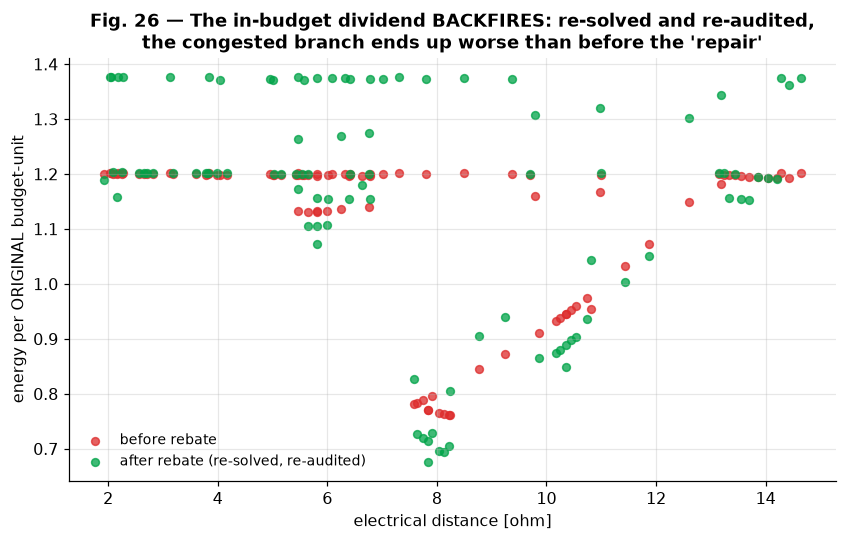

In [8]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
order = np.argsort(fdr.dist_ohm)
ax.scatter(fdr.dist_ohm, z, s=26, color=PALETTE[2], alpha=0.75, label="before rebate")
ax.scatter(fdr.dist_ohm, z2, s=26, color=PALETTE[1], alpha=0.75, label="after rebate (re-solved, re-audited)")
ax.set_xlabel("electrical distance [ohm]"); ax.set_ylabel("energy per ORIGINAL budget-unit")
ax.set_title("Fig. 26 — The in-budget dividend BACKFIRES: re-solved and re-audited,\n"
             "the congested branch ends up worse than before the 'repair'")
ax.legend(fontsize=9)
savefig(fig, RESULTS / "fig26_repair.png")
plt.show()

**The obvious repair backfires — and the numbers say exactly why.** Every
fairness metric moved the *wrong* way: Jain fell, Gini rose, and the congested
branch — the intended beneficiary — lost further purchasing power while the rest
of the feeder gained. Two mechanisms, both visible in the printout:

1. **In a sell-all market, money cannot buy more energy — only higher prices.**
   Total consumption is pinned at $\Sigma P$ = 19.0 MW by the equilibrium
   itself; injecting the rebate into budgets is pure demand-pull inflation
   (M1's Fig. 6c told us prices are linear in total budget). The dividend
   changes *who* outbids *whom*, nothing else.
2. **The rebound is regressive here:** the congested-branch households spend
   part of their rebate re-stimulating demand *behind the binding constraint*,
   and the dual ascent answers with +31% higher congestion revenue — clawing
   back their dividend and then some, while unconstrained households enjoy
   their rebate at full value. The transfer leaked through the constraint it
   was meant to compensate for.

A negative result, kept — because it teaches the design rule: **a fairness
transfer must not re-excite the constraint that created the unfairness.** Which
suggests the fix: pay the compensation *outside* the energy market — cash that
does not enter next period's energy budget cannot inflate prices or rebound.
That variant needs no new equilibrium at all (the allocation is untouched); it
is arithmetic on the ledger:

In [9]:
div = R_tau / fdr.N
z_equal = x / (g11.C - div)          # equal dividend as outside money
z_ftr = x / (g11.C - pay_tau)        # pro-rata: each household's own congestion
                                     # payment returned as outside money (FTR-style)
comp = pd.DataFrame({
    "scheme": ["no repair", "in-budget equal dividend (re-solved)",
               "outside-money equal dividend", "outside-money pro-rata rebate"],
    "Jain": [S.jain(z), S.jain(z2), S.jain(z_equal), S.jain(z_ftr)],
    "Gini": [S.gini(z), S.gini(z2), S.gini(z_equal), S.gini(z_ftr)],
    "branch/rest ratio": [z[branch].mean() / z[~branch].mean(),
                          z2[branch].mean() / z2[~branch].mean(),
                          z_equal[branch].mean() / z_equal[~branch].mean(),
                          z_ftr[branch].mean() / z_ftr[~branch].mean()],
    "rebound": ["—", f"+{100 * (pay2.sum() / R_tau - 1):.0f}% revenue",
                "none", "none"],
})
print(comp.round(4).to_string(index=False))
print("\n(z = energy per net outlay; branch/rest ratio 1.0 = the branch is made whole)")

                              scheme   Jain   Gini  branch/rest ratio      rebound
                           no repair 0.9834 0.0588             0.7331            —
in-budget equal dividend (re-solved) 0.9702 0.0940             0.6694 +31% revenue
        outside-money equal dividend 0.9698 0.0970             0.6976         none
       outside-money pro-rata rebate 0.9999 0.0047             0.9781         none


(z = energy per net outlay; branch/rest ratio 1.0 = the branch is made whole)

**Second surprise: the equal dividend fails even as outside money.** Jain and
the branch/rest ratio barely move or worsen — because an equal-per-household
dividend targets the *small*, and the congested-branch households are the
feeder's *large* consumers (that is partly why their branch binds). A transfer
aimed at a location-based injustice but keyed to household size mostly misses
its target. Targeting is not a detail; it is the design.

**The scheme that works is the pro-rata rebate** — each household receives its
*own congestion payment* back, as money outside the energy budget. Net outlay
then equals the pure energy cost, and the ledger equalizes almost perfectly
(bottom row: Jain ≈ 1, branch made whole, zero rebound, physics untouched).
Power-market veterans will recognize the design: it is the logic of **financial
transmission rights** — charge congestion *at the margin* where it steers
behavior, return the rent *infra-marginally* where it cannot. Two honest
caveats, stated plainly: (1) in one-shot play the ex-post rebate leaves the
marginal signal intact, but households who *anticipate* being rebated in
repeated play would learn to ignore the charge — dynamic incentive erosion is a
real design constraint, flagged not solved; (2) making the branch whole in
money still does not give it more energy — at fixed $\Sigma P$ nothing can;
this is compensation, not correction.

The efficiency–fairness picture is now four computed points: efficient-and-unfair
(no repair); *less* fair through the intuitive repair (in-budget dividend —
market dynamics ate it); still unfair with better accounting (equal outside
dividend — mistargeted); repaired (pro-rata outside rebate — FTR logic). Two of
the four repairs failed, and the failures were caught by re-solving and
re-measuring rather than by assumption. **FATE properties of a market mechanism
can be computed, audited, repaired — and the repairs themselves can fail and be
caught — with the same physics-gated rigor as its power flows.** Fairness
engineering, not fairness rhetoric.

## §5 · The learning tax, by location

One more line in the ledger, connecting M3: while households *learn* the
equilibrium, each pays a regret — utility lost to exploration and error,
relative to the clairvoyant response. Nobody invoices this tax, but it is real,
and the question fits this notebook: **is it also location-biased?**

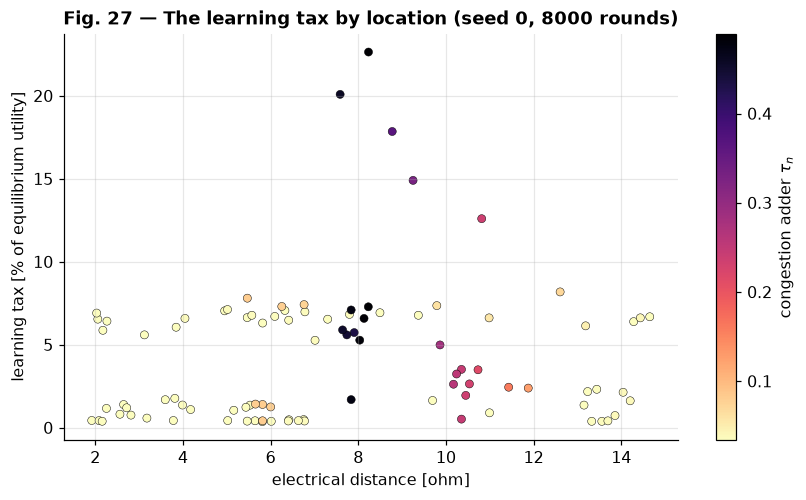

learning tax, % of equilibrium utility: congested branch 7.00%, rest 3.40%

In [10]:
r11 = L.run_coupled(g11, n_rounds=8000, seed=0, tau=asc.tau,
                    y_ref=asc.y, x_ref=NG.best_response_tau(g11, asc.y, asc.tau),
                    log_every=20)
tax = r11.regret_n[-1]                       # running-mean per-round regret, end of run
u_eq = g11.alpha * np.log(g11.beta[:, None] + NG.best_response_tau(g11, asc.y, asc.tau)).sum(axis=1)
tax_rel = 100 * tax / np.abs(u_eq)

fig, ax = plt.subplots(figsize=(9.0, 4.8))
sc = ax.scatter(fdr.dist_ohm, tax_rel, s=28, c=asc.tau, cmap="magma_r",
                edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=ax, label=r"congestion adder $\tau_n$")
ax.set_xlabel("electrical distance [ohm]")
ax.set_ylabel("learning tax [% of equilibrium utility]")
ax.set_title("Fig. 27 — The learning tax by location (seed 0, 8000 rounds)")
savefig(fig, RESULTS / "fig27_learning_tax.png")
plt.show()

print(f"learning tax, % of equilibrium utility: congested branch "
      f"{tax_rel[branch].mean():.2f}%, rest {tax_rel[~branch].mean():.2f}%")

**The learning burden is also location-biased — about 2× heavier on the
congested branch** (7.0% vs 3.4% of equilibrium utility, printed above). A
plausible mechanism, offered as hypothesis rather than proof (single seed,
LEDGER M4-A4): the branch households face higher effective prices, hence
smaller feasible budget sets and lower equilibrium utilities — the same absolute
exploration noise costs them relatively more. Whatever the mechanism, the
methodological point stands: once regret is measured *per household* and joined
to the feeder's geography, "is the learning burden fairly distributed?" becomes
an answerable question — and its first answer is *no, the physics biases this
too*. The constrained branch pays three times: in congestion charges, in reduced
purchasing power, and in learning tax.

## §6 · Capstone: what this repository showed

| M | Claim, in one line | Where |
|---|---|---|
| 1 | The canonical Stackelberg DR game, recreated and verified against its paper — with its distributed algorithm revealed as an integral controller | nb 02 |
| 2 | On a real feeder the blind equilibrium breaks physics at γ\*=0.9; per-bus dual-ascent repricing lifts hosting capacity +89% and prices constraint *responsibility*, not distance | nb 03 |
| 3 | Comfort-feedback-only learners find the exact equilibrium ~100× slower and their flicker permanently spends the voltage margin — equilibria certify points, learning occupies neighborhoods | nb 04 |
| 4 | The congestion charges pass a Shapley cost-causation audit (marginal ≈ average-marginal on a near-linear feeder); the naive in-budget repair *backfires* (+31% rebound — caught by re-solving) while outside-money compensation repairs cleanly; every bill is explainable | nb 05 |

**The through-line:** one auditable stack — game → physics → learning →
fairness — where every layer is graded against the exact layer below it: the
recreation against the paper, the feeder market against AC power flow, the
learners against the analytical equilibrium, the fairness repair against the
re-solved world. Nothing rests on a simulation nobody checked.

**Open questions this prototype deliberately leaves on the table** (the
research agenda beyond this prototype): adaptive congestion pricing *against* learning agents (the
efficiency-vs-robustness tension of nb 04 §6); constraint-aware or safe
learning; multi-period coupling, storage, and DER; P2P/coalition markets in
virtual microgrids; formal FATE metrics beyond Jain/Gini/Shapley; and
mechanism design under the EU AI Act's transparency obligations, for which the
Shapley bill explanation of §3 is a concrete starting artifact.